In [1]:
import os
os.environ['JAX_PLATFORMS'] = 'cpu'
import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from functools import partial
from dataclasses import dataclass

from flab.empirics import ExptTrace, rcsetup

print(f"JAX backend: {jax.default_backend()}")

ModuleNotFoundError: No module named 'flab'

# Setup

In [2]:
def loss_fn(params, target):
    W2, W1 = params["W2"], params["W1"]
    return 0.5 * jnp.linalg.norm(target - W1 @ W2.T)**2

def polar_factor(G):
    U, _, Vt = jnp.linalg.svd(G, full_matrices=False)
    return U @ Vt

@partial(jax.jit, static_argnames=['lr'])
def step_fn(params, target, lr):
    loss, grads = jax.value_and_grad(loss_fn)(params, target)
    updates = jax.tree.map(lambda g: -lr * polar_factor(g), grads)
    new_params = jax.tree.map(lambda p, u: p + u, params, updates)
    return new_params, loss

# Testing the LR Schedule

In [ ]:
"""
Low-rank factorization training: fit W1 @ W2.T to a target diagonal
spectrum via gradient steps, tracking singular values and loss over time.
"""

@dataclass
class Hypers:
    d: int = 25
    V: int = 25
    num_steps: int = 16
    rng: int = 42
    lr: float = 1e-4
    init_scale: float = 1e-4


H = Hypers()

key = jax.random.PRNGKey(H.rng)
k1, k2 = jax.random.split(key, num=2)

# Target spectrum: decaying singular values 1 / (offset + i), normalized
# so the largest singular value is 1.
OFFSET = 4
target_spectrum = (OFFSET + np.arange(1, H.V + 1)) ** -1.0
target_spectrum = target_spectrum / target_spectrum.max()
target = jnp.diag(target_spectrum)

# Orthogonal init for W1, W2: QR decomposition of Gaussian noise, with a
# sign correction so the orthogonal factor doesn't have an arbitrary sign
# flip per column, then scaled down by init_scale.
W1_raw = jax.random.normal(k1, (H.V, H.d))
W2_raw = jax.random.normal(k2, (H.V, H.d))
Q1, R1 = jnp.linalg.qr(W1_raw)
Q2, R2 = jnp.linalg.qr(W2_raw)
params = {
    "W1": Q1 * H.init_scale * jnp.sign(jnp.diag(R1)),
    "W2": Q2 * H.init_scale * jnp.sign(jnp.diag(R2)),
}

losses, svs, lrs = ExptTrace.multi_init(3, ["t"])

for nstep in tqdm(range(H.num_steps)):
    # Track the singular values of the effective product matrix W1 @ W2.T.
    _, S1, _ = jnp.linalg.svd(params["W1"] @ params["W2"].T, full_matrices=False)
    svs[nstep] = S1

    params, loss = step_fn(params, target, H.lr)

    lrs[nstep] = H.lr
    losses[nstep] = loss

    # LR schedule: jump to sqrt(0.5) right after the first step, then halve
    # on every subsequent step.
    if nstep == 0:
        H.lr = np.sqrt(max(target_spectrum))
    else:
        H.lr *= 0.5

100%|██████████| 16/16 [00:01<00:00, 10.35it/s]


# Plotting

<>:59: SyntaxWarning: invalid escape sequence '\e'
<>:59: SyntaxWarning: invalid escape sequence '\e'
/var/folders/y0/sc7jmx7n2vs9kmrjt2zyfpk00000gn/T/ipykernel_80381/808896504.py:59: SyntaxWarning: invalid escape sequence '\e'
  ax.set_ylabel(f'$\eta(t)$')
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


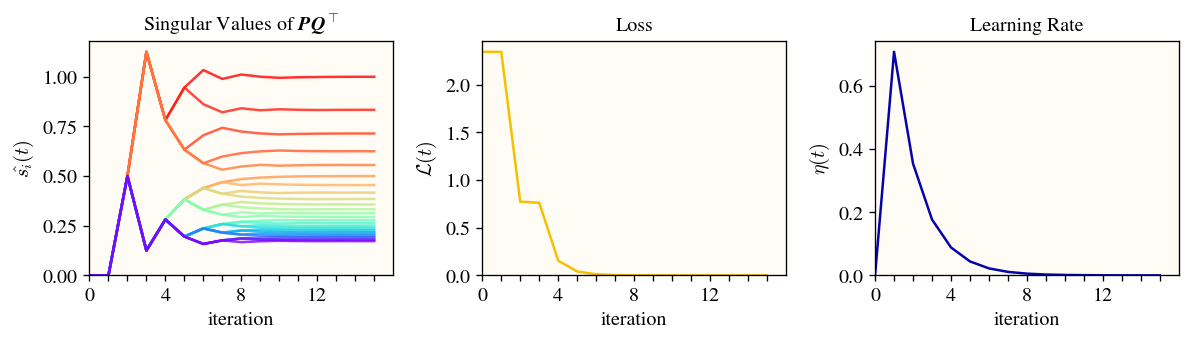

In [ ]:
rcsetup(panel_color='parchment')

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes = axes.flat

ax = axes[0]
cmap = plt.cm.rainbow
n = min(H.V, H.d)
colors = [cmap(1 - i / (n - 1)) for i in range(n)]

for i in range(n):
    ax.plot(svs.get_axis("t"), svs[:][:, i], color=colors[i], alpha=0.8)
ax.set_xlabel(f'iteration')
ax.set_ylabel(r'$\hat{s_i}(t)$')
ticks = range(0, H.num_steps)
labels = [i if i % 4 == 0 else "" for i in ticks]
ax.set_xticks(ticks=ticks, labels=labels)
ax.set_xbound(0,H.num_steps)
ax.set_ylim(bottom=0)
ax.set_title(r'Singular Values of $\boldsymbol{P}\boldsymbol{Q}^\top$')

ax = axes[1]
ax.plot(losses.get_axis("t"), losses[:], color='xkcd:golden')
ax.set_xlabel(f'iteration')
ax.set_ylabel(r'$\mathcal{L}(t)$')
ticks = range(0, H.num_steps)
labels = [i if i % 4 == 0 else "" for i in ticks]
ax.set_xticks(ticks=ticks, labels=labels)
ax.set_ylim(bottom=0)
ax.set_xbound(0,H.num_steps)
ax.set_title('Loss')

ax = axes[2]
ax.plot(losses.get_axis("t"), lrs[:], color='xkcd:royal blue')
ax.set_xlabel(f'iteration')
ax.set_ylabel(f'$\eta(t)$')
ax.set_ylim(bottom=0)
ticks = range(0, H.num_steps)
labels = [i if i % 4 == 0 else "" for i in ticks]
ax.set_xticks(ticks=ticks, labels=labels)
ax.set_xbound(0,H.num_steps)
ax.set_title('Learning Rate')

plt.tight_layout()
plt.savefig("fig4.pdf", bbox_inches="tight")
plt.show()